# Conditional Diffusion Training

This notebook uses the project code directly instead of duplicating path, dataset, and training logic. Training images are read from `data/images/<run-id>/message.png`, and condition labels are read from the matching `output/json/**/<run-id>.json`. Set `LABEL_SOURCE = "final-hash"` to train the new final-hash conditional model, or `LABEL_SOURCE = "step4"` to reproduce the existing `Logs/4th Step` model.
The example config uses `fit_mode="height-flatten"` to use the `ImgConfig.img_size` height as the unit, flatten ImgConfig-sized blocks, and then reshape to a square RGB image; the source dimensions must be multiples of `ImgConfig.img_size` (28x28 by default). `reshape` remains available for equal-area square conversion.

Label mapping:
- input image: `data/images/<run-id>/message.png`
- condition label: `output/json/**/<run-id>.json` -> `Generated hash` when `LABEL_SOURCE="final-hash"`, otherwise `Logs/4th Step`


## Imports

The only manual bootstrap here is a fallback for running the notebook before `pip install -e .`. After that, project paths come from `OutputConfig`, and training parameters come from `ConditionalDiffusionTrainConfig`.

In [1]:
from dataclasses import asdict, replace
from pathlib import Path
import json
import sys


def add_local_src_to_path() -> Path:
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        src = candidate / "src"
        if (candidate / "pyproject.toml").exists() and (src / "diffusion_hash_inv").exists():
            if str(src) not in sys.path:
                sys.path.insert(0, str(src))
            return candidate
    raise RuntimeError("Project root with src/diffusion_hash_inv was not found.")


try:
    from diffusion_hash_inv.config import OutputConfig
except ModuleNotFoundError:
    add_local_src_to_path()
    from diffusion_hash_inv.config import OutputConfig

import torch
from IPython.display import display
from PIL import Image

from diffusion_hash_inv.models.conditional_diffusion import (
    ConditionalDiffusionTrainConfig,
    GeneratedImageDataset,
    cleanup_torch_resources,
    discover_loop_image_samples,
    save_image_grid,
    train_conditional_diffusion,
)


## Project Paths

`OutputConfig` is the codebase-level source of truth for the project root and output directories.

In [2]:
output_cfg = OutputConfig()

DATA_ROOT = output_cfg.data_dir / "images"
JSON_ROOT = output_cfg.output_dir / "json"
LABEL_SOURCE = "final-hash"  # use "step4" for the existing Logs/4th Step label model
LABEL_RUN_NAME = LABEL_SOURCE.replace("-", "_")
NOTEBOOK_OUTPUT_DIR = output_cfg.output_dir / "conditional_diffusion_notebook" / LABEL_RUN_NAME
FULL_OUTPUT_ROOT = output_cfg.output_dir / (
    "conditional_diffusion_final_hash"
    if LABEL_SOURCE == "final-hash"
    else "conditional_diffusion"
)

assert DATA_ROOT.exists(), DATA_ROOT
assert JSON_ROOT.exists(), JSON_ROOT
NOTEBOOK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(output_cfg)
print("Image root:", DATA_ROOT)
print("JSON root:", JSON_ROOT)
print("Label source:", LABEL_SOURCE)
print("Notebook output:", NOTEBOOK_OUTPUT_DIR)
print("Full training output root:", FULL_OUTPUT_ROOT)


OutputConfig
  Root Directory: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse,
  Data Directory: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data,
  Output Directory: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output,
  EMNIST Directory: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/EMNIST,
  Encoding: 'utf-8'

Image root: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data/images
JSON root: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/json
Label source: final-hash
Notebook output: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/conditional_diffusion_notebook/final_hash
Full training output root: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/conditional_diffusion_final_hash


## Training Config

All parameters are collected in `ConditionalDiffusionTrainConfig`. The smoke config is intentionally small so the full pipeline can be verified quickly. `label_source` is passed through from `LABEL_SOURCE`; the current notebook default is the final-hash conditional model.
With `fit_mode="height-flatten"`, input images use the `ImgConfig.img_size` height as the unit, flatten ImgConfig-sized blocks, and reshape to a square RGB image. `reshape` is still available for equal-area square conversion.
When process traces are enabled, forward traces are saved for every diffusion timestep; `trace_steps` controls reverse trace sampling only.

For custom beta schedules, set `beta_schedule` to `file`, `hash-approach1`, or `hash-approach2`. Use `beta_values_path` with `file`.

In [3]:
smoke_config = ConditionalDiffusionTrainConfig(
    data_root=DATA_ROOT,
    json_root=JSON_ROOT,
    output_dir=NOTEBOOK_OUTPUT_DIR / "smoke",
    image_size=32,
    channels=3,
    fit_mode="height-flatten",
    label_source=LABEL_SOURCE,
    max_images=256,
    batch_size=8,
    train_steps=3,
    epochs=None,
    timesteps=4,
    learning_rate=2e-4,
    base_channels=8,
    time_dim=16,
    beta_schedule="hash-approach1",
    sample_count=1,
    save_process_traces=True,
    trace_sample_count=1,
    # trace_steps is compatibility-only; reverse traces are saved for all timesteps.
    trace_steps=4,
    save_train_batches_every=5,
    device="cpu",
    log_every=1,
)

asdict(smoke_config)


{'data_root': PosixPath('/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data/images'),
 'json_root': PosixPath('/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/json'),
 'output_dir': PosixPath('/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/conditional_diffusion_notebook/final_hash/smoke'),
 'image_size': 32,
 'channels': 3,
 'fit_mode': 'height-flatten',
 'condition_mode': 'json-step',
 'label_source': 'final-hash',
 'max_images': 256,
 'batch_size': 8,
 'train_steps': 3,
 'epochs': None,
 'timesteps': 4,
 'learning_rate': 0.0002,
 'base_channels': 8,
 'time_dim': 16,
 'beta_start': 0.0001,
 'beta_end': 0.02,
 'beta_schedule': 'hash-approach1',
 'beta_values_path': None,
 'beta_schedule_step': '4th Step',
 'device': 'cpu',
 'seed': 0,
 'num_workers': 0,
 'log_every': 1,
 'sample_every': 0,
 'checkpoint_every': 0,
 'sample_count': 1,
 'save_process_traces': True,
 'trace_sample_count': 1,
 'trace_steps': 4,
 'save_train_batches_eve

## Dataset Preview

`GeneratedImageDataset` uses the same config fields as the trainer. This preview confirms `message.png`-only sampling and the selected label source before training starts.

In [4]:
def dataset_from_config(config: ConditionalDiffusionTrainConfig) -> GeneratedImageDataset:
    return GeneratedImageDataset(
        config.data_root,
        json_root=config.json_root,
        image_size=config.image_size,
        channels=config.channels,
        fit_mode=config.fit_mode,
        label_source=config.label_source,
        max_images=config.max_images,
        use_loop_images=config.use_loop_images,
        max_loop_count=config.max_loop_count,
    )


dataset = dataset_from_config(smoke_config)
print("dataset size:", len(dataset))
print("num conditions:", dataset.num_conditions)
print("label source:", dataset.label_source)

for sample in dataset.samples[:10]:
    relative_path = sample.path.relative_to(smoke_config.data_root)
    preview = sample.condition if len(sample.condition) <= 120 else sample.condition[:120] + "..."
    print(f"label={sample.label:03d} path={relative_path} condition={preview}")


dataset size: 256
num conditions: 256
label source: final-hash
label=051 path=MD5_128_2026-05-11 14-28-52_0000/message.png condition=0x2f560167b7d642aa549906bad5c60a2c
label=052 path=MD5_128_2026-05-11 14-28-52_0001/message.png condition=0x2f5e0ebc0a44cca31d64dca5d0f4579c
label=236 path=MD5_128_2026-05-11 14-28-52_0002/message.png condition=0xef69ad0b1be849babbf3fcc1a5dc482f
label=197 path=MD5_128_2026-05-11 14-28-52_0003/message.png condition=0xb89f5ffc3a9ca272e827085ff55798d8
label=085 path=MD5_128_2026-05-11 14-28-52_0004/message.png condition=0x53d47ef175784b9113161e3471584dee
label=032 path=MD5_128_2026-05-11 14-28-52_0005/message.png condition=0x22f2ccf8ed37011084b7809412211de2
label=078 path=MD5_128_2026-05-11 14-28-52_0006/message.png condition=0x4bb5e95d6a6d430b69d18a167e81c6da
label=235 path=MD5_128_2026-05-11 14-28-52_0007/message.png condition=0xece06e575a6940ac5f4cad19bd70adb4
label=096 path=MD5_128_2026-05-11 14-28-52_0008/message.png condition=0x5c8bc090fafc8761892535fe7

## Image Preview

`save_image_grid` is reused from the training module and now writes per-sample PNG files (`name_000.png`, ...).

preview base: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/conditional_diffusion_notebook/final_hash/dataset_preview.png
preview files: ['dataset_preview_000.png', 'dataset_preview_001.png', 'dataset_preview_002.png', 'dataset_preview_003.png']


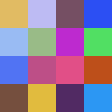

preview labels: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/conditional_diffusion_notebook/final_hash/dataset_preview.labels.json
[
  {
    "index": 0,
    "file": "dataset_preview_000.png",
    "label": 51,
    "condition": "0x2f560167b7d642aa549906bad5c60a2c"
  },
  {
    "index": 1,
    "file": "dataset_preview_001.png",
    "label": 52,
    "condition": "0x2f5e0ebc0a44cca31d64dca5d0f4579c"
  },
  {
    "index": 2,
    "file": "dataset_preview_002.png",
    "label": 236,
    "condition": "0xef69ad0b1be849babbf3fcc1a5dc482f"
  },
  {
    "index": 3,
    "file": "dataset_preview_003.png",
    "label": 197,
    "condition": "0xb89f5ffc3a9ca272e827085ff55798d8"
  }
]


In [5]:
def save_dataset_preview(
    dataset: GeneratedImageDataset,
    output_path: Path,
    count: int = 8,
) -> tuple[Path, list[Path], Path]:
    images = []
    labels = []
    for idx in range(min(count, len(dataset))):
        image, label, _ = dataset[idx]
        images.append(image)
        labels.append(int(label))

    save_image_grid(
        torch.stack(images),
        torch.tensor(labels, dtype=torch.long),
        dataset.condition_names,
        output_path,
    )
    labels_path = output_path.with_suffix(".labels.json")
    saved_files = sorted(output_path.parent.glob(f"{output_path.stem}*.png"))
    return output_path, saved_files, labels_path


preview_base, preview_files, preview_labels = save_dataset_preview(
    dataset,
    NOTEBOOK_OUTPUT_DIR / "dataset_preview.png",
    4,
)
print("preview base:", preview_base)
print("preview files:", [path.name for path in preview_files])
display(Image.open(preview_files[0]))
print("preview labels:", preview_labels)
print(preview_labels.read_text(encoding=output_cfg.encoding)[:600])


## Smoke Training

This calls the same `train_conditional_diffusion` entry point used by the CLI.
When `save_process_traces=True`, forward trace progress is printed to stdout for every diffusion step.

In [6]:
RUN_SMOKE_TRAIN = False
if RUN_SMOKE_TRAIN:
    smoke_result = train_conditional_diffusion(smoke_config)
    print(smoke_result)
else:
    smoke_result = None
    print("Set RUN_SMOKE_TRAIN = True to start the smoke run.")


Set RUN_SMOKE_TRAIN = True to start the smoke run.


## Inspect Samples

The `.labels.json` file maps each saved sample PNG file to the selected condition label.

In [7]:
if smoke_result is None:
    print("Run the smoke training cell first by setting RUN_SMOKE_TRAIN = True.")
else:
    sample_base = Path(smoke_result["sample_grid"])
    sample_labels = sample_base.with_suffix(".labels.json")
    sample_files = sorted(sample_base.parent.glob(f"{sample_base.stem}*.png"))

    print("sample base:", sample_base)
    print("sample files:", [path.name for path in sample_files])
    for path in sample_files[:4]:
        display(Image.open(path))

    print("sample labels:", sample_labels)
    print(sample_labels.read_text(encoding=output_cfg.encoding)[:1000])


Run the smoke training cell first by setting RUN_SMOKE_TRAIN = True.


## Inspect Forward / Reverse Process Traces

Forward traces show noising from real dataset images for every timestep and the training cell stdout includes per-step `[forward-trace]` logs. Reverse traces show denoising from random noise for selected timesteps and condition labels.

In [8]:
if smoke_result is None:
    print("Run the smoke training cell first by setting RUN_SMOKE_TRAIN = True.")
else:
    trace_root = Path(smoke_result["process_traces"])
    forward_images = sorted((trace_root / "forward").glob("*.png"))
    reverse_images = sorted((trace_root / "reverse").glob("*.png"))

    beta_schedule = json.loads(Path(smoke_result["beta_schedule"]).read_text(encoding=output_cfg.encoding))
    effective_timesteps = int(beta_schedule["timesteps"])
    expected_forward = (effective_timesteps + 1) * smoke_config.trace_sample_count
    expected_reverse = (effective_timesteps + 1) * smoke_config.trace_sample_count

    print(f"forward trace files ({len(forward_images)} total, expected {expected_forward}):")
    for path in forward_images:
        print(" ", path.name)

    print(f"reverse trace files ({len(reverse_images)} total, expected {expected_reverse}):")
    for path in reverse_images:
        print(" ", path.name)

    display(Image.open(forward_images[0]))
    display(Image.open(reverse_images[0]))


Run the smoke training cell first by setting RUN_SMOKE_TRAIN = True.


In [9]:
import mlx.core as mx

def mem_cleanup(*names: str):
    for name in names:
        globals().pop(name, None)
    cleanup_torch_resources()

## Full Training Config

The full config is derived from the smoke config with `dataclasses.replace`, so only the values that differ are listed here.

In [10]:
mem_cleanup("smoke_result", "dataset")
RUN_FULL_TRAIN = True

full_config = replace(
    smoke_config,
    output_dir=FULL_OUTPUT_ROOT / "Approach1",
    image_size=64,
    max_images=None,
    batch_size=32,
    train_steps=1000,
    epochs=1,
    timesteps=200,
    base_channels=64,
    time_dim=256,
    beta_schedule="hash-approach1",
    sample_count=16,
    save_process_traces=True,
    trace_sample_count=1,
    # trace_steps is compatibility-only; reverse traces are saved for all timesteps.
    save_train_batches_every=5,
    device="auto",
    log_every=50,
    sample_every=0,
    checkpoint_every=0,
)

if RUN_FULL_TRAIN:
    full_result = train_conditional_diffusion(full_config)
    print(full_result)
else:
    print("Set RUN_FULL_TRAIN = True to start the longer run.")
    asdict(full_config)

[reshape] mode=height-flatten source=448x28 img_size=28x28 blocks=16 (4x4) output=112x112 channels=3
dataset=10000 images conditions=10000 steps=313 epochs=1 device=mps beta_schedule=hash-approach1 diffusion_timesteps=1056 sample_image_shape=(3, 112, 112) output=/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/conditional_diffusion_final_hash/Approach1
step=000001 loss=1.120602
saved train batch: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/conditional_diffusion_final_hash/Approach1/train_batches/step_000005.png
saved train batch metadata: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/conditional_diffusion_final_hash/Approach1/train_batches/step_000005.batch.json
saved train batch: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/conditional_diffusion_final_hash/Approach1/train_batches/step_000010.png
saved train batch metadata: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/conditio

In [11]:
mem_cleanup("full_result", "full_config")

In [12]:
RUN_FULL_TRAIN = True

full_config = replace(
    smoke_config,
    output_dir=FULL_OUTPUT_ROOT / "Approach2",
    image_size=64,
    max_images=None,
    batch_size=32,
    train_steps=1000,
    epochs=1,
    timesteps=200,
    base_channels=64,
    time_dim=256,
    beta_schedule="hash-approach2",
    sample_count=16,
    save_process_traces=True,
    trace_sample_count=1,
    # trace_steps is compatibility-only; reverse traces are saved for all timesteps.
    save_train_batches_every=5,
    device="auto",
    log_every=50,
    sample_every=0,
    checkpoint_every=0,
)

if RUN_FULL_TRAIN:
    full_result = train_conditional_diffusion(full_config)
    print(full_result)
else:
    print("Set RUN_FULL_TRAIN = True to start the longer run.")
    asdict(full_config)


[reshape] mode=height-flatten source=448x28 img_size=28x28 blocks=16 (4x4) output=112x112 channels=3
dataset=10000 images conditions=10000 steps=313 epochs=1 device=mps beta_schedule=hash-approach2 diffusion_timesteps=1056 sample_image_shape=(3, 112, 112) output=/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/conditional_diffusion_final_hash/Approach2
step=000001 loss=1.123021
saved train batch: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/conditional_diffusion_final_hash/Approach2/train_batches/step_000005.png
saved train batch metadata: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/conditional_diffusion_final_hash/Approach2/train_batches/step_000005.batch.json
saved train batch: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/conditional_diffusion_final_hash/Approach2/train_batches/step_000010.png
saved train batch metadata: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/conditio

In [13]:
mem_cleanup("full_result", "full_config")

In [14]:
RUN_FULL_TRAIN = True

full_config = replace(
    smoke_config,
    output_dir=FULL_OUTPUT_ROOT / "Linear",
    image_size=64,
    max_images=None,
    batch_size=32,
    train_steps=1000,
    epochs=1,
    timesteps="auto",
    base_channels=64,
    time_dim=256,
    beta_schedule="linear",
    sample_count=16,
    save_process_traces=True,
    trace_sample_count=1,
    # trace_steps is compatibility-only; reverse traces are saved for all timesteps.
    save_train_batches_every=5,
    device="auto",
    log_every=50,
    sample_every=0,
    checkpoint_every=0,
)

if RUN_FULL_TRAIN:
    full_result = train_conditional_diffusion(full_config)
    print(full_result)
else:
    print("Set RUN_FULL_TRAIN = True to start the longer run.")
    asdict(full_config)



[reshape] mode=height-flatten source=448x28 img_size=28x28 blocks=16 (4x4) output=112x112 channels=3
dataset=10000 images conditions=10000 steps=313 epochs=1 device=mps beta_schedule=linear diffusion_timesteps=1056 sample_image_shape=(3, 112, 112) output=/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/conditional_diffusion_final_hash/Linear
step=000001 loss=1.122974
saved train batch: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/conditional_diffusion_final_hash/Linear/train_batches/step_000005.png
saved train batch metadata: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/conditional_diffusion_final_hash/Linear/train_batches/step_000005.batch.json
saved train batch: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/conditional_diffusion_final_hash/Linear/train_batches/step_000010.png
saved train batch metadata: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/conditional_diffusion_final_

In [15]:
mem_cleanup("full_result", "full_config")

## Temporal Conditioning

The three loop-aware conditioning modes expose the ordinal/temporal structure of the 64-loop sequence to the model:

| mode | description |
|------|-------------|
| `loop-sinusoidal` | Sinusoidal PE on `loop_idx`; adjacent loops share similar embeddings |
| `loop-structured` | Sum of sinusoidal PE + separate start/end boundary projections |
| `loop-sequence`   | Transformer encoder over all `max_loop_count` loop tokens; each loop sees the full sequence context |

Set `use_loop_images=True` to load per-loop PNGs (`4th Step / 1st Round / NNth Loop.png`) instead of `message.png`.
Leave it `False` to keep using `message.png` while still enriching the condition embedding with loop ordinal metadata.

### Method 1 – Loop Sinusoidal

Replaces the independent `nn.Embedding` with a fixed sinusoidal positional encoding on the loop index, followed by a 2-layer MLP. Loop 1 and Loop 2 will be geometrically closer in embedding space than Loop 1 and Loop 64.

In [ ]:
mem_cleanup("full_result", "full_config")
RUN_TEMPORAL_TRAIN = False  # set True to run

TEMPORAL_OUTPUT_ROOT = output_cfg.output_dir / "conditional_diffusion_temporal"

loop_sinusoidal_config = replace(
    smoke_config,
    output_dir=TEMPORAL_OUTPUT_ROOT / "LoopSinusoidal",
    image_size=64,
    max_images=None,
    batch_size=32,
    train_steps=1000,
    epochs=1,
    timesteps="auto",
    base_channels=64,
    time_dim=256,
    beta_schedule="hash-approach1",
    sample_count=16,
    save_process_traces=False,
    save_train_batches_every=0,
    device="auto",
    log_every=50,
    sample_every=0,
    checkpoint_every=0,
    # ── temporal conditioning ──
    temporal_conditioning="loop-sinusoidal",
    use_loop_images=False,   # True to load per-loop PNGs
    max_loop_count=64,
)

if RUN_TEMPORAL_TRAIN:
    result_sinusoidal = train_conditional_diffusion(loop_sinusoidal_config)
    print(result_sinusoidal)
else:
    print("Set RUN_TEMPORAL_TRAIN = True to start training.")
    asdict(loop_sinusoidal_config)

In [ ]:
mem_cleanup("result_sinusoidal", "loop_sinusoidal_config")


### Method 2 – Loop Structured

Three independent projections are summed:
1. Sinusoidal PE on `loop_idx`
2. Linear projection of normalised `loop_start` scalar
3. Linear projection of normalised `loop_end` scalar

This gives the model separate axes to reason about *where* in the sequence the loop falls and what slice of the hash state it covers.

In [ ]:
RUN_TEMPORAL_TRAIN = False  # set True to run

loop_structured_config = replace(
    smoke_config,
    output_dir=TEMPORAL_OUTPUT_ROOT / "LoopStructured",
    image_size=64,
    max_images=None,
    batch_size=32,
    train_steps=1000,
    epochs=1,
    timesteps="auto",
    base_channels=64,
    time_dim=256,
    beta_schedule="hash-approach1",
    sample_count=16,
    save_process_traces=False,
    save_train_batches_every=0,
    device="auto",
    log_every=50,
    sample_every=0,
    checkpoint_every=0,
    # ── temporal conditioning ──
    temporal_conditioning="loop-structured",
    use_loop_images=False,
    max_loop_count=64,
)

if RUN_TEMPORAL_TRAIN:
    result_structured = train_conditional_diffusion(loop_structured_config)
    print(result_structured)
else:
    print("Set RUN_TEMPORAL_TRAIN = True to start training.")
    asdict(loop_structured_config)

In [ ]:
mem_cleanup("result_structured", "loop_structured_config")


### Method 3 – Loop Sequence (Transformer)

A small Transformer encoder runs over all `max_loop_count` learnable loop tokens at each forward pass, so every loop's embedding is informed by the full sequence context (bidirectional).

This is the most expressive option but costs one transformer forward pass per training step. With `max_loop_count=64` and `time_dim=256` the overhead is small.

Set `use_loop_images=True` here to load the actual per-loop images so the model sees both the pixel content *and* the sequence-level context.

In [ ]:
RUN_TEMPORAL_TRAIN = False  # set True to run

loop_sequence_config = replace(
    smoke_config,
    output_dir=TEMPORAL_OUTPUT_ROOT / "LoopSequence",
    image_size=64,
    max_images=None,
    batch_size=32,
    train_steps=1000,
    epochs=1,
    timesteps="auto",
    base_channels=64,
    time_dim=256,
    beta_schedule="hash-approach1",
    sample_count=16,
    save_process_traces=False,
    save_train_batches_every=0,
    device="auto",
    log_every=50,
    sample_every=0,
    checkpoint_every=0,
    # ── temporal conditioning ──
    temporal_conditioning="loop-sequence",
    use_loop_images=True,   # load per-loop PNGs for full context
    max_loop_count=64,
)

if RUN_TEMPORAL_TRAIN:
    result_sequence = train_conditional_diffusion(loop_sequence_config)
    print(result_sequence)
else:
    print("Set RUN_TEMPORAL_TRAIN = True to start training.")
    asdict(loop_sequence_config)

In [ ]:
mem_cleanup("result_sequence", "loop_sequence_config")
